# Data Testing — Processed Tables
Sanity checks and quality validation for `matches.csv`, `players.csv`, and `teams.csv`.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import config

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 1. Load Tables

In [2]:
matches = pd.read_csv(config.DATA_PROCESSED / 'matches.csv')
players = pd.read_csv(config.DATA_PROCESSED / 'players.csv')
teams   = pd.read_csv(config.DATA_PROCESSED / 'teams.csv')

print(f'matches : {matches.shape}')
print(f'players : {players.shape}')
print(f'teams   : {teams.shape}')

matches : (276, 9)
players : (8650, 35)
teams   : (552, 11)


## 2. Schema & dtypes

In [3]:
print('=== matches ===')
print(matches.dtypes)
print()
print('=== players ===')
print(players.dtypes)
print()
print('=== teams ===')
print(teams.dtypes)

=== matches ===
match_id           int64
date_str           int64
home_team_id       int64
home_team_name    object
away_team_id       int64
away_team_name    object
home_score         int64
away_score         int64
total_events       int64
dtype: object

=== players ===
player_id                   float64
team_id                       int64
total_passes                  int64
accurate_passes               int64
key_passes                    int64
through_balls                 int64
long_balls                    int64
crosses                       int64
progressive_passes            int64
passes_into_final_third       int64
passes_into_penalty_area      int64
assists                       int64
shot_creating_actions         int64
successful_dribbles           int64
total_dribbles                int64
progressive_carries           int64
shots                         int64
goals                         int64
tackles                       int64
interceptions                 int64
ball_rec

## 3. Null Values

In [4]:
for name, df in [('matches', matches), ('players', players), ('teams', teams)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    pct   = (nulls / len(df) * 100).round(1)
    print(f'=== {name} — {len(df)} rows ===')
    if nulls.empty:
        print('  No nulls.')
    else:
        print(pd.concat([nulls.rename('null_count'), pct.rename('null_%')], axis=1).to_string())
    print()

=== matches — 276 rows ===
  No nulls.

=== players — 8650 rows ===
        null_count  null_%
rating        8650  100.00

=== teams — 552 rows ===
  No nulls.



## 4. Duplicate Checks

In [5]:
# matches: each match_id should appear once
dup_matches = matches[matches.duplicated('match_id', keep=False)]
print(f'Duplicate match_ids in matches: {len(dup_matches)}')

# players: each (player_id, match_id) should be unique
dup_players = players[players.duplicated(['player_id', 'match_id'], keep=False)]
print(f'Duplicate (player_id, match_id) in players: {len(dup_players)}')

# teams: each (team_id, match_id) should be unique
dup_teams = teams[teams.duplicated(['team_id', 'match_id'], keep=False)]
print(f'Duplicate (team_id, match_id) in teams: {len(dup_teams)}')

Duplicate match_ids in matches: 0
Duplicate (player_id, match_id) in players: 0
Duplicate (team_id, match_id) in teams: 0


## 5. Matches — Quick Glance

In [6]:
matches.head(10)

,match_id,date_str,home_team_id,home_team_name,away_team_id,away_team_name,home_score,away_score,total_events
0,1901138,1022026,300,Atalanta,1290,Como,0,0,1595
1,1901140,1022026,2731,Cremonese,75,Inter,0,2,1503
2,1901146,1022026,87,Juventus,24341,Parma Calcio 1913,5,0,1496
3,1901150,1022026,79,Lecce,72,Torino,0,1,1504
4,1901379,1032026,80,AC Milan,2731,Cremonese,2,0,1493
5,1901383,1032026,84,Roma,87,Juventus,3,3,1544
6,1901386,1032026,77,Lazio,72,Torino,0,2,1684
7,1901387,1032026,2889,Sassuolo,300,Atalanta,2,1,1514
8,1901204,1112025,2731,Cremonese,87,Juventus,1,2,1527
9,1901212,1112025,276,Napoli,1290,Como,0,0,1513


In [7]:
# Score distribution
matches['total_goals'] = matches['home_score'] + matches['away_score']
print('Goals per game stats:')
print(matches['total_goals'].describe())
print()
print('Events per match stats:')
print(matches['total_events'].describe())

Goals per game stats:
count   276.00
mean      2.44
std       1.52
min       0.00
25%       1.00
50%       2.00
75%       3.00
max       8.00
Name: total_goals, dtype: float64

Events per match stats:
count    276.00
mean    1483.12
std       86.50
min     1215.00
25%     1423.50
50%     1490.00
75%     1536.50
max     1717.00
Name: total_events, dtype: float64


In [8]:
# Teams represented
home_teams = set(matches['home_team_name'].dropna())
away_teams = set(matches['away_team_name'].dropna())
all_teams  = home_teams | away_teams
print(f'Teams in dataset ({len(all_teams)}):')
for t in sorted(all_teams):
    print(f'  {t}')

Teams in dataset (20):
  AC Milan
  Atalanta
  Bologna
  Cagliari
  Como
  Cremonese
  Fiorentina
  Genoa
  Inter
  Juventus
  Lazio
  Lecce
  Napoli
  Parma Calcio 1913
  Pisa
  Roma
  Sassuolo
  Torino
  Udinese
  Verona


## 6. Players — Quick Glance

In [9]:
players.head(10)

,player_id,team_id,total_passes,accurate_passes,key_passes,through_balls,long_balls,crosses,progressive_passes,passes_into_final_third,passes_into_penalty_area,assists,shot_creating_actions,successful_dribbles,total_dribbles,progressive_carries,shots,goals,tackles,interceptions,ball_recoveries,clearances,aerials_won,touches_final_third,touches,match_id,team_name,position,age,minutes_played,isFirstEleven,height,weight,rating,player_name
0,85070.00,300,28,17,0,0,4,0,3,1,0,0,0,0,0,0,0,0,4,0,4,2,0,4,40,1901138,Atalanta,MC,34,98,True,186,76,NaN,Marten de Roon
1,90782.00,1290,16,15,1,0,2,1,3,7,1,0,1,0,0,0,0,0,0,0,0,0,0,5,16,1901138,Como,Sub,34,10,False,178,68,NaN,Sergi Roberto
2,91213.00,1290,7,6,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,10,12,1901138,Como,Sub,33,39,False,190,84,NaN,Álvaro Morata
3,100962.00,300,18,13,0,0,1,0,1,1,0,0,0,0,0,0,0,0,2,0,4,10,3,1,32,1901138,Atalanta,DC,33,98,True,190,83,NaN,Berat Djimsiti
4,116465.00,1290,115,109,2,0,0,0,13,9,2,3,2,0,0,0,2,0,0,1,4,5,11,20,126,1901138,Como,DC,31,98,True,186,87,NaN,Marc Oliver Kempf
5,141312.00,300,34,20,0,0,14,3,9,3,1,0,2,2,3,0,0,0,2,0,5,4,0,11,47,1901138,Atalanta,DMR,33,98,True,182,70,NaN,Davide Zappacosta
6,228854.00,1290,14,13,0,0,1,0,2,0,1,1,1,1,1,0,2,0,1,0,0,0,0,13,21,1901138,Como,AMR,31,47,True,187,78,NaN,Mërgim Vojvoda
7,256536.00,1290,30,29,0,0,4,0,6,0,0,0,0,0,0,0,0,0,0,0,6,1,0,0,34,1901138,Como,GK,30,98,True,188,70,NaN,Jean Butez
8,302650.00,300,2,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,2,4,1901138,Atalanta,FW,27,17,True,196,85,NaN,Gianluca Scamacca
9,349184.00,300,7,3,0,0,1,1,1,0,0,0,1,1,1,0,0,0,0,1,2,1,0,2,12,1901138,Atalanta,Sub,25,40,False,188,82,NaN,Raoul Bellanova


In [10]:
print(f'Unique players  : {players["player_id"].nunique()}')
print(f'Unique matches  : {players["match_id"].nunique()}')
print(f'Avg players/match: {players.groupby("match_id").size().mean():.1f}')

Unique players  : 552
Unique matches  : 276
Avg players/match: 31.3


In [11]:
# Stat summary
stat_cols = [
    'total_passes', 'key_passes', 'through_balls', 'progressive_passes',
    'passes_into_final_third', 'passes_into_penalty_area',
    'shot_creating_actions', 'successful_dribbles',
    'progressive_carries', 'shots', 'goals'
]
available = [c for c in stat_cols if c in players.columns]
players[available].describe().T

,count,mean,std,min,25%,50%,75%,max
total_passes,8650.00,29.87,21.95,0.00,12.00,27.00,43.00,130.00
key_passes,8650.00,0.59,0.97,0.00,0.00,0.00,1.00,9.00
through_balls,8650.00,0.06,0.28,0.00,0.00,0.00,0.00,5.00
progressive_passes,8650.00,3.76,3.78,0.00,1.00,3.00,6.00,33.00
passes_into_final_third,8650.00,1.98,2.49,0.00,0.00,1.00,3.00,24.00
passes_into_penalty_area,8650.00,0.76,1.22,0.00,0.00,0.00,1.00,13.00
shot_creating_actions,8650.00,0.99,1.39,0.00,0.00,0.00,2.00,14.00
successful_dribbles,8650.00,0.39,0.80,0.00,0.00,0.00,1.00,10.00
progressive_carries,8650.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
shots,8650.00,0.80,1.16,0.00,0.00,0.00,1.00,8.00


count   8650.00
mean      66.77
std       31.99
min        0.00
25%       35.00
50%       80.00
75%       95.00
max      103.00
Name: minutes_played, dtype: float64


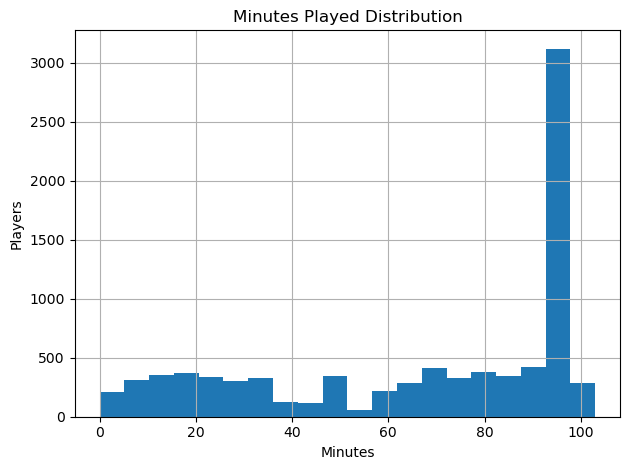

In [12]:
# Minutes played distribution (if available)
if 'minutes_played' in players.columns:
    print(players['minutes_played'].describe())
    players['minutes_played'].hist(bins=20)
    plt.title('Minutes Played Distribution')
    plt.xlabel('Minutes')
    plt.ylabel('Players')
    plt.tight_layout()
    plt.show()
else:
    print('minutes_played column not present.')

In [13]:
# Position breakdown
if 'position' in players.columns:
    print(players['position'].value_counts())
else:
    print('position column not present.')

position
Sub    2578
DC     1457
MC     1266
FW      795
GK      552
AMC     321
DMR     320
DML     320
DL      205
DR      205
DMC     177
FWL      99
FWR      99
AMR      74
AML      74
MR       54
ML       54
Name: count, dtype: int64


## 7. Sanity Checks — Stats Validity

In [14]:
issues = []

# Key passes can't exceed total passes
if {'key_passes', 'total_passes'}.issubset(players.columns):
    bad = players[players['key_passes'] > players['total_passes']]
    issues.append(f'key_passes > total_passes: {len(bad)} rows')

# Accurate passes can't exceed total passes
if {'accurate_passes', 'total_passes'}.issubset(players.columns):
    bad = players[players['accurate_passes'] > players['total_passes']]
    issues.append(f'accurate_passes > total_passes: {len(bad)} rows')

# Successful dribbles can't exceed total dribbles
if {'successful_dribbles', 'total_dribbles'}.issubset(players.columns):
    bad = players[players['successful_dribbles'] > players['total_dribbles']]
    issues.append(f'successful_dribbles > total_dribbles: {len(bad)} rows')

# No negative values in any stat column
for col in available:
    neg = (players[col] < 0).sum()
    if neg > 0:
        issues.append(f'Negative values in {col}: {neg} rows')

if issues:
    print('Issues found:')
    for i in issues:
        print(f'  [!] {i}')
else:
    print('All sanity checks passed.')

Issues found:
  [!] key_passes > total_passes: 0 rows
  [!] accurate_passes > total_passes: 0 rows
  [!] successful_dribbles > total_dribbles: 0 rows


## 8. Top Chance Creators (raw counts)

In [15]:
# Aggregate across all matches per player
agg_cols = [c for c in available if c in players.columns]
group_cols = ['player_id']
if 'player_name' in players.columns:
    group_cols.append('player_name')
if 'team_name' in players.columns:
    group_cols.append('team_name')
if 'position' in players.columns:
    group_cols.append('position')

player_totals = (
    players
    .groupby(group_cols, as_index=False)[agg_cols + (['minutes_played'] if 'minutes_played' in players.columns else [])]
    .sum()
)

# Top 15 by key passes
if 'key_passes' in player_totals.columns:
    display_cols = [c for c in ['player_name', 'team_name', 'position', 'minutes_played',
                                'key_passes', 'shot_creating_actions', 'through_balls',
                                'passes_into_penalty_area', 'goals'] if c in player_totals.columns]
    print('Top 15 by key passes (all matches):')
    print(player_totals.nlargest(15, 'key_passes')[display_cols].to_string(index=False))

Top 15 by key passes (all matches):
         player_name         team_name position  minutes_played  key_passes  shot_creating_actions  through_balls  passes_into_penalty_area  goals
    Federico Dimarco             Inter      DML            1909          61                     66              1                        86      5
      Nicolò Barella             Inter       MC            1747          51                     67              6                        75      1
        Kenan Yildiz          Juventus      AMC            1538          46                     85              4                        54      6
        Aarón Martín             Genoa      DML            1302          44                     50              0                        53      1
        Juan Miranda           Bologna       DL            1755          43                     47              4                        54      1
         Luka Modric          AC Milan       MC            2215          41       

## 9. Teams Table Check

In [16]:
teams.head(10)

,match_id,team_id,team_name,is_home,total_passes,accurate_passes,total_shots,goals,key_passes,tackles,interceptions
0,1901138,300,Atalanta,True,224,134,6,0,4,23,9
1,1901138,1290,Como,False,818,734,28,0,23,8,6
2,1901140,2731,Cremonese,True,315,222,9,0,6,15,4
3,1901140,75,Inter,False,686,590,15,2,11,8,4
4,1901146,87,Juventus,True,598,509,16,5,10,17,8
5,1901146,24341,Parma Calcio 1913,False,397,320,10,0,7,9,14
6,1901150,79,Lecce,True,503,376,14,0,7,13,2
7,1901150,72,Torino,False,355,260,17,1,13,30,8
8,1901379,80,AC Milan,True,478,401,20,2,18,14,10
9,1901379,2731,Cremonese,False,420,320,15,0,11,16,7


In [17]:
# Home vs away pass accuracy comparison
if {'accurate_passes', 'total_passes', 'is_home'}.issubset(teams.columns):
    teams['pass_acc'] = teams['accurate_passes'] / teams['total_passes'].replace(0, np.nan)
    print(teams.groupby('is_home')['pass_acc'].describe())

         count  mean  std  min  25%  50%  75%  max
is_home                                           
False   276.00  0.80 0.06 0.62 0.77 0.81 0.84 0.91
True    276.00  0.79 0.06 0.59 0.75 0.80 0.84 0.92


## 10. Match Coverage Check

In [18]:
# Compare extracted match IDs vs match_ids.csv
match_ids_file = config.ROOT_DIR / 'data' / 'match_ids.csv'
if match_ids_file.exists():
    expected = pd.read_csv(match_ids_file)['match_id'].astype(str).tolist()
    extracted = matches['match_id'].astype(str).tolist()
    missing = set(expected) - set(extracted)
    print(f'Expected matches : {len(expected)}')
    print(f'Extracted matches: {len(extracted)}')
    print(f'Missing          : {len(missing)}')
    if missing:
        print('Missing IDs (first 20):', sorted(missing)[:20])
else:
    print('match_ids.csv not found.')

Expected matches : 276
Extracted matches: 276
Missing          : 0
